In [35]:
import torch
import matplotlib.pyplot as plt
import numpy as np

# Set random seed for reproducibility
torch.manual_seed(42)
np.random.seed(42)

In [36]:
class RecurrentNeuralNetwork:
    def __init__(self, input_size, hidden_size, output_size, learning_rate=0.01):
        """
        Vanilla RNN implementation from scratch
        
        Parameters:
        -----------
        input_size : int
            Dimension of input features
        hidden_size : int
            Dimension of hidden state
        output_size : int
            Dimension of output
        learning_rate : float
            Learning rate for gradient descent
        """
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.output_size = output_size
        self.learning_rate = learning_rate
        
        # Initialize weights
        # W_xh: input to hidden (input_size x hidden_size)
        # W_hh: hidden to hidden (hidden_size x hidden_size)
        # W_hy: hidden to output (hidden_size x output_size)
        
        # Xavier initialization
        limit_xh = np.sqrt(6.0 / (input_size + hidden_size))
        limit_hh = np.sqrt(6.0 / (hidden_size + hidden_size))
        limit_hy = np.sqrt(6.0 / (hidden_size + output_size))
        
        self.W_xh = torch.rand(input_size, hidden_size) * 2 * limit_xh - limit_xh
        self.W_hh = torch.rand(hidden_size, hidden_size) * 2 * limit_hh - limit_hh
        self.W_hy = torch.rand(hidden_size, output_size) * 2 * limit_hy - limit_hy
        
        # Initialize biases
        self.b_h = torch.zeros(hidden_size)
        self.b_y = torch.zeros(output_size)
        
        # Training history
        self.loss_history = []
    
    def tanh(self, x):
        """Tanh activation"""
        return torch.tanh(x)
    
    def tanh_derivative(self, x):
        """Derivative of tanh"""
        return 1.0 - torch.tanh(x) ** 2
    
    def forward(self, X, return_hidden=False):
        """
        Forward pass through RNN
        
        Parameters:
        -----------
        X : torch.Tensor
            Input sequence of shape (seq_length, input_size) or (batch_size, seq_length, input_size)
        return_hidden : bool
            Whether to return hidden states and z values
        
        Returns:
        --------
        outputs : torch.Tensor
            Output sequence
        hidden_states : list (if return_hidden=True)
            Hidden states at each time step
        z_hiddens : list (if return_hidden=True)
            Pre-activation values for hidden states
        """
        # Handle single sequence or batch
        if X.dim() == 2:
            X = X.unsqueeze(0)  # Add batch dimension
        
        batch_size, seq_length, _ = X.shape
        
        # Initialize hidden state
        h = torch.zeros(batch_size, self.hidden_size)
        
        # Store states for backpropagation
        hidden_states = [h]
        z_hiddens = []
        outputs = []
        
        # Process sequence
        for t in range(seq_length):
            x_t = X[:, t, :]  # Input at time t
            
            # Hidden state: h_t = tanh(W_xh @ x_t + W_hh @ h_{t-1} + b_h)
            z_h = x_t @ self.W_xh + h @ self.W_hh + self.b_h
            h = self.tanh(z_h)
            
            # Output: y_t = W_hy @ h_t + b_y
            y_t = h @ self.W_hy + self.b_y
            
            hidden_states.append(h)
            z_hiddens.append(z_h)
            outputs.append(y_t)
        
        # Stack outputs
        outputs = torch.stack(outputs, dim=1)  # (batch_size, seq_length, output_size)
        
        if return_hidden:
            return outputs, hidden_states, z_hiddens
        return outputs
    
    def backward(self, X, y, outputs, hidden_states, z_hiddens):
        """
        Backpropagation Through Time (BPTT)
        
        Parameters:
        -----------
        X : torch.Tensor
            Input sequence
        y : torch.Tensor
            Target sequence
        outputs : torch.Tensor
            Predicted outputs
        hidden_states : list
            Hidden states from forward pass
        z_hiddens : list
            Pre-activation values
        """
        if X.dim() == 2:
            X = X.unsqueeze(0)
        if y.dim() == 2:
            y = y.unsqueeze(0)
        
        batch_size, seq_length, _ = X.shape
        
        # Initialize gradients
        dW_xh = torch.zeros_like(self.W_xh)
        dW_hh = torch.zeros_like(self.W_hh)
        dW_hy = torch.zeros_like(self.W_hy)
        db_h = torch.zeros_like(self.b_h)
        db_y = torch.zeros_like(self.b_y)
        
        # Gradient of hidden state (for BPTT)
        dh_next = torch.zeros(batch_size, self.hidden_size)
        
        # Backpropagate through time
        for t in reversed(range(seq_length)):
            # Output error
            dy = outputs[:, t, :] - y[:, t, :]
            
            # Gradients for output layer
            dW_hy += hidden_states[t+1].T @ dy
            db_y += dy.sum(dim=0)
            
            # Backpropagate to hidden state
            dh = dy @ self.W_hy.T + dh_next
            
            # Backpropagate through tanh
            dz_h = dh * self.tanh_derivative(z_hiddens[t])
            
            # Gradients for hidden layer
            dW_xh += X[:, t, :].T @ dz_h
            dW_hh += hidden_states[t].T @ dz_h
            db_h += dz_h.sum(dim=0)
            
            # Pass gradient to next time step
            dh_next = dz_h @ self.W_hh.T
        
        # Average gradients over batch and sequence
        dW_xh /= (batch_size * seq_length)
        dW_hh /= (batch_size * seq_length)
        dW_hy /= (batch_size * seq_length)
        db_h /= (batch_size * seq_length)
        db_y /= (batch_size * seq_length)
        
        # Gradient clipping (prevent exploding gradients)
        clip_value = 5.0
        dW_xh = torch.clamp(dW_xh, -clip_value, clip_value)
        dW_hh = torch.clamp(dW_hh, -clip_value, clip_value)
        dW_hy = torch.clamp(dW_hy, -clip_value, clip_value)
        db_h = torch.clamp(db_h, -clip_value, clip_value)
        db_y = torch.clamp(db_y, -clip_value, clip_value)
        
        # Update weights
        self.W_xh -= self.learning_rate * dW_xh
        self.W_hh -= self.learning_rate * dW_hh
        self.W_hy -= self.learning_rate * dW_hy
        self.b_h -= self.learning_rate * db_h
        self.b_y -= self.learning_rate * db_y
    
    def compute_loss(self, outputs, y):
        """
        Compute Mean Squared Error loss
        """
        if y.dim() == 2:
            y = y.unsqueeze(0)
        loss = torch.mean((outputs - y) ** 2)
        return loss.item()
    
    def fit(self, X, y, epochs=100, verbose=True):
        """
        Train the RNN
        
        Parameters:
        -----------
        X : torch.Tensor
            Input sequences of shape (n_samples, seq_length, input_size)
        y : torch.Tensor
            Target sequences of shape (n_samples, seq_length, output_size)
        epochs : int
            Number of training epochs
        verbose : bool
            Print training progress
        """
        if verbose:
            print(f"Training RNN")
            print(f"Input size: {self.input_size}")
            print(f"Hidden size: {self.hidden_size}")
            print(f"Output size: {self.output_size}")
            print(f"Learning rate: {self.learning_rate}")
            print(f"Epochs: {epochs}\n")
        
        for epoch in range(epochs):
            # Forward pass
            outputs, hidden_states, z_hiddens = self.forward(X, return_hidden=True)
            
            # Compute loss
            loss = self.compute_loss(outputs, y)
            self.loss_history.append(loss)
            
            # Backward pass
            self.backward(X, y, outputs, hidden_states, z_hiddens)
            
            # Print progress
            if verbose and (epoch % 10 == 0 or epoch == epochs - 1):
                print(f"Epoch {epoch:4d}: Loss = {loss:.6f}")
        
        if verbose:
            print("\nTraining completed!")
        
        return self
    
    def predict(self, X):
        """
        Make predictions
        """
        outputs = self.forward(X, return_hidden=False)
        return outputs

Input shape: torch.Size([480, 20, 1])
Target shape: torch.Size([480, 20, 1])


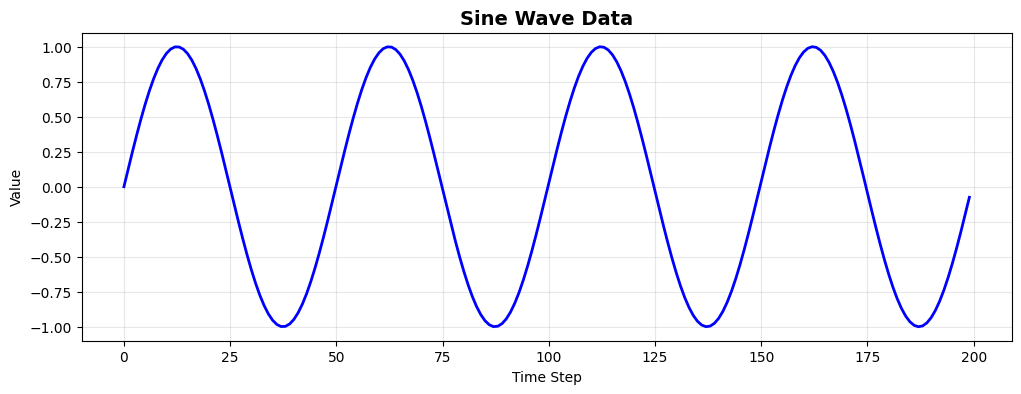

In [37]:
# Generate sine wave data
def generate_sine_wave(n_samples=1000, seq_length=20):
    """
    Generate sine wave sequences for prediction
    """
    t = torch.linspace(0, 20 * np.pi, n_samples)
    data = torch.sin(t)
    
    # Create sequences
    X = []
    y = []
    
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length].unsqueeze(1))  # Input: seq_length x 1
        y.append(data[i+1:i+seq_length+1].unsqueeze(1))  # Target: next step
    
    X = torch.stack(X)  # (n_samples, seq_length, 1)
    y = torch.stack(y)  # (n_samples, seq_length, 1)
    
    return X, y, data

# Generate data
X_sine, y_sine, full_sine = generate_sine_wave(n_samples=500, seq_length=20)

print(f"Input shape: {X_sine.shape}")
print(f"Target shape: {y_sine.shape}")

# Visualize sine wave
plt.figure(figsize=(12, 4))
plt.plot(full_sine[:200], 'b-', linewidth=2)
plt.title('Sine Wave Data', fontsize=14, fontweight='bold')
plt.xlabel('Time Step')
plt.ylabel('Value')
plt.grid(True, alpha=0.3)
plt.show()

In [38]:
# Train RNN on sine wave
print("=" * 60)
print("SINE WAVE PREDICTION")
print("=" * 60 + "\n")

rnn_sine = RecurrentNeuralNetwork(
    input_size=1,
    hidden_size=32,
    output_size=1,
    learning_rate=0.01
)

rnn_sine.fit(X_sine, y_sine, epochs=100, verbose=True)

SINE WAVE PREDICTION

Training RNN
Input size: 1
Hidden size: 32
Output size: 1
Learning rate: 0.01
Epochs: 100

Epoch    0: Loss = 0.407641
Epoch   10: Loss = 0.176692
Epoch   20: Loss = 0.101113
Epoch   30: Loss = 0.069724
Epoch   40: Loss = 0.053224
Epoch   50: Loss = 0.043305
Epoch   60: Loss = 0.036949
Epoch   70: Loss = 0.032704
Epoch   80: Loss = 0.029746
Epoch   90: Loss = 0.027581
Epoch   99: Loss = 0.026062

Training completed!


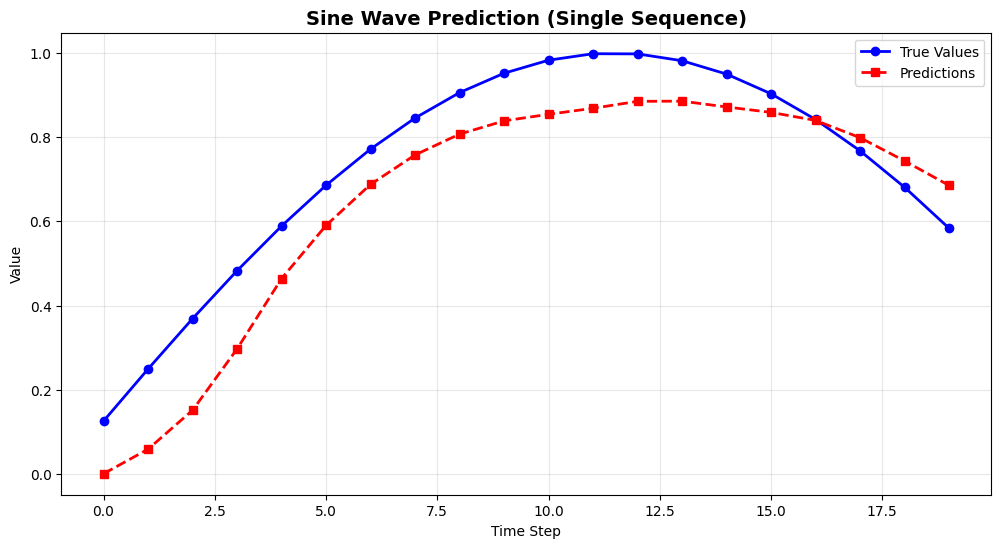


Mean Squared Error: 0.013715


In [39]:
# Evaluate and visualize predictions
test_seq = X_sine[0:1]  # First sequence
predictions = rnn_sine.predict(test_seq)

plt.figure(figsize=(12, 6))
plt.plot(y_sine[0, :, 0].numpy(), 'b-', linewidth=2, label='True Values', marker='o')
plt.plot(predictions[0, :, 0].detach().numpy(), 'r--', linewidth=2, label='Predictions', marker='s')
plt.title('Sine Wave Prediction (Single Sequence)', fontsize=14, fontweight='bold')
plt.xlabel('Time Step')
plt.ylabel('Value')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Calculate error
error = torch.mean((predictions[0, :, 0] - y_sine[0, :, 0]) ** 2).item()
print(f"\nMean Squared Error: {error:.6f}")

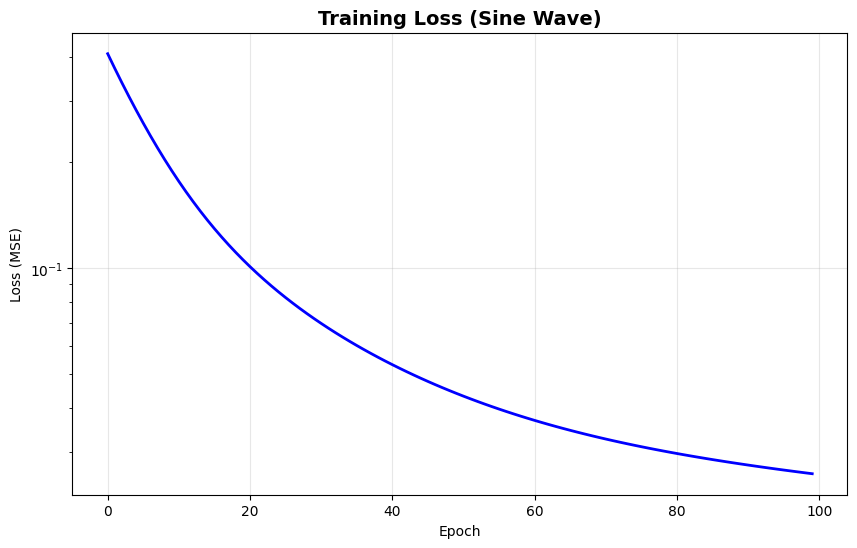

Initial loss: 0.407641
Final loss: 0.026062


In [40]:
# Plot training loss
plt.figure(figsize=(10, 6))
plt.plot(rnn_sine.loss_history, 'b-', linewidth=2)
plt.title('Training Loss (Sine Wave)', fontsize=14, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.grid(True, alpha=0.3)
plt.yscale('log')
plt.show()

print(f"Initial loss: {rnn_sine.loss_history[0]:.6f}")
print(f"Final loss: {rnn_sine.loss_history[-1]:.6f}")

Input shape: torch.Size([200, 10, 1])
Target shape: torch.Size([200, 10, 1])


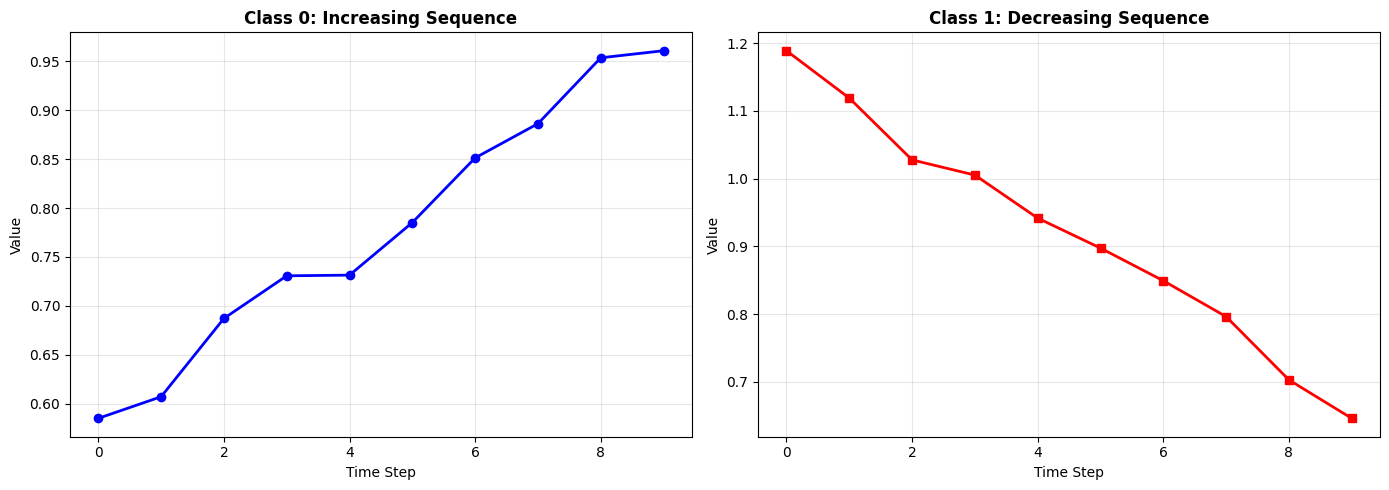

In [41]:
# Generate sequence classification data
def generate_sequence_data(n_samples=200, seq_length=10):
    """
    Generate two types of sequences:
    - Class 0: Increasing sequences
    - Class 1: Decreasing sequences
    """
    X = []
    y = []
    
    for i in range(n_samples // 2):
        # Increasing sequence (class 0)
        start = torch.rand(1) * 0.5
        seq = start + torch.cumsum(torch.rand(seq_length) * 0.1, dim=0)
        X.append(seq.unsqueeze(1))
        # Label for each time step (class 0)
        y.append(torch.zeros(seq_length, 1))
    
    for i in range(n_samples // 2):
        # Decreasing sequence (class 1)
        start = torch.rand(1) * 0.5 + 1.0
        seq = start - torch.cumsum(torch.rand(seq_length) * 0.1, dim=0)
        X.append(seq.unsqueeze(1))
        # Label for each time step (class 1)
        y.append(torch.ones(seq_length, 1))
    
    X = torch.stack(X)
    y = torch.stack(y)
    
    # Shuffle
    indices = torch.randperm(n_samples)
    X = X[indices]
    y = y[indices]
    
    return X, y

# Generate data
X_seq, y_seq = generate_sequence_data(n_samples=200, seq_length=10)

print(f"Input shape: {X_seq.shape}")
print(f"Target shape: {y_seq.shape}")

# Visualize sample sequences
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Class 0 example
class_0_idx = (y_seq[:, 0, 0] == 0).nonzero()[0].item()
axes[0].plot(X_seq[class_0_idx, :, 0].numpy(), 'b-', linewidth=2, marker='o')
axes[0].set_title('Class 0: Increasing Sequence', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Time Step')
axes[0].set_ylabel('Value')
axes[0].grid(True, alpha=0.3)

# Class 1 example
class_1_idx = (y_seq[:, 0, 0] == 1).nonzero()[0].item()
axes[1].plot(X_seq[class_1_idx, :, 0].numpy(), 'r-', linewidth=2, marker='s')
axes[1].set_title('Class 1: Decreasing Sequence', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Time Step')
axes[1].set_ylabel('Value')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [42]:
# Train RNN for sequence classification
print("=" * 60)
print("SEQUENCE CLASSIFICATION")
print("=" * 60 + "\n")

rnn_clf = RecurrentNeuralNetwork(
    input_size=1,
    hidden_size=16,
    output_size=1,
    learning_rate=0.01
)

rnn_clf.fit(X_seq, y_seq, epochs=100, verbose=True)

SEQUENCE CLASSIFICATION

Training RNN
Input size: 1
Hidden size: 16
Output size: 1
Learning rate: 0.01
Epochs: 100

Epoch    0: Loss = 0.250799
Epoch   10: Loss = 0.185464
Epoch   20: Loss = 0.166773
Epoch   30: Loss = 0.158198
Epoch   40: Loss = 0.151980
Epoch   50: Loss = 0.146367
Epoch   60: Loss = 0.140940
Epoch   70: Loss = 0.135584
Epoch   80: Loss = 0.130265
Epoch   90: Loss = 0.124976
Epoch   99: Loss = 0.120255

Training completed!



Classification Accuracy: 70.50%
Correctly classified: 141 / 200


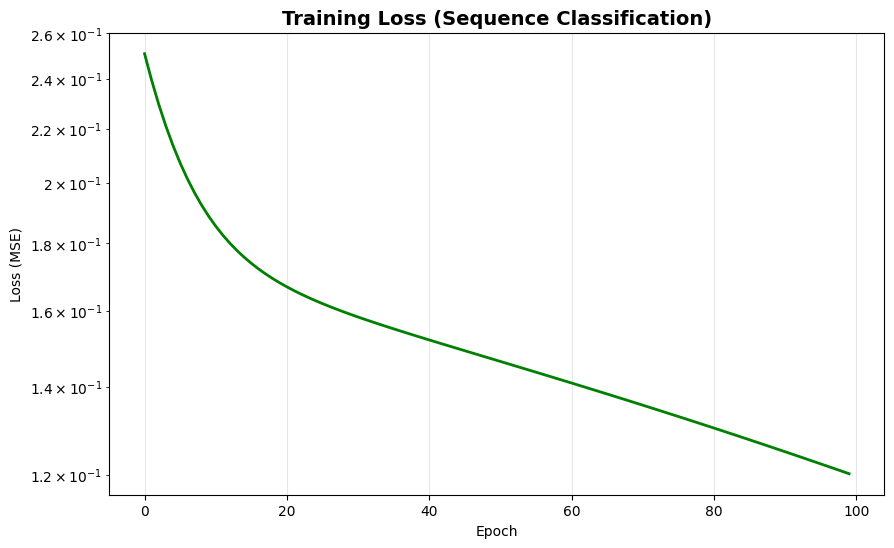

In [43]:
# Evaluate classification accuracy
predictions_clf = rnn_clf.predict(X_seq)
predicted_classes = (predictions_clf[:, -1, 0] > 0.5).long()  # Use last time step
true_classes = y_seq[:, -1, 0].long()

accuracy = (predicted_classes == true_classes).float().mean().item()

print(f"\nClassification Accuracy: {accuracy * 100:.2f}%")
print(f"Correctly classified: {(predicted_classes == true_classes).sum().item()} / {len(true_classes)}")

# Plot training loss
plt.figure(figsize=(10, 6))
plt.plot(rnn_clf.loss_history, 'g-', linewidth=2)
plt.title('Training Loss (Sequence Classification)', fontsize=14, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.grid(True, alpha=0.3)
plt.yscale('log')
plt.show()

In [44]:
print("=" * 70)
print("SIMPLE SEQUENCE MEMORIZATION")
print("=" * 70)

# Create a simple sequence to memorize
simple_seq = torch.tensor([[0.1, 0.2, 0.3, 0.4, 0.5]]).unsqueeze(2)  # (1, 5, 1)
simple_target = torch.tensor([[0.2, 0.3, 0.4, 0.5, 0.6]]).unsqueeze(2)  # Next value

print(f"\nInput sequence: {simple_seq.squeeze().tolist()}")
print(f"Target sequence: {simple_target.squeeze().tolist()}")
print(f"Pattern: Each output is input + 0.1\n")

# Small RNN
rnn_simple = RecurrentNeuralNetwork(
    input_size=1,
    hidden_size=8,
    output_size=1,
    learning_rate=0.05
)

print("=" * 70)
print("Training...")
print("=" * 70 + "\n")

# Train
rnn_simple.fit(simple_seq, simple_target, epochs=200, verbose=True)

SIMPLE SEQUENCE MEMORIZATION

Input sequence: [0.10000000149011612, 0.20000000298023224, 0.30000001192092896, 0.4000000059604645, 0.5]
Target sequence: [0.20000000298023224, 0.30000001192092896, 0.4000000059604645, 0.5, 0.6000000238418579]
Pattern: Each output is input + 0.1

Training...

Training RNN
Input size: 1
Hidden size: 8
Output size: 1
Learning rate: 0.05
Epochs: 200

Epoch    0: Loss = 0.603766
Epoch   10: Loss = 0.110802
Epoch   20: Loss = 0.056506
Epoch   30: Loss = 0.039446
Epoch   40: Loss = 0.029086
Epoch   50: Loss = 0.021749
Epoch   60: Loss = 0.016355
Epoch   70: Loss = 0.012346
Epoch   80: Loss = 0.009368
Epoch   90: Loss = 0.007169
Epoch  100: Loss = 0.005557
Epoch  110: Loss = 0.004385
Epoch  120: Loss = 0.003535
Epoch  130: Loss = 0.002921
Epoch  140: Loss = 0.002476
Epoch  150: Loss = 0.002151
Epoch  160: Loss = 0.001910
Epoch  170: Loss = 0.001729
Epoch  180: Loss = 0.001588
Epoch  190: Loss = 0.001477
Epoch  199: Loss = 0.001394

Training completed!


In [45]:
# Test the learned sequence
prediction = rnn_simple.predict(simple_seq)

print("\n" + "=" * 70)
print("RESULTS")
print("=" * 70)

print(f"\n{'Time':<8} {'Input':<12} {'Target':<12} {'Predicted':<12} {'Error'}")
print("=" * 70)

for t in range(len(simple_seq[0])):
    inp = simple_seq[0, t, 0].item()
    target = simple_target[0, t, 0].item()
    pred = prediction[0, t, 0].item()
    error = abs(target - pred)
    print(f"{t:<8} {inp:<12.4f} {target:<12.4f} {pred:<12.4f} {error:.6f}")

mse = torch.mean((prediction[0, :, 0] - simple_target.squeeze()) ** 2).item()
print(f"\nMean Squared Error: {mse:.6f}")


RESULTS

Time     Input        Target       Predicted    Error
0        0.1000       0.2000       0.2433       0.043286
1        0.2000       0.3000       0.2627       0.037272
2        0.3000       0.4000       0.4334       0.033436
3        0.4000       0.5000       0.5188       0.018792
4        0.5000       0.6000       0.5531       0.046865

Mean Squared Error: 0.001386


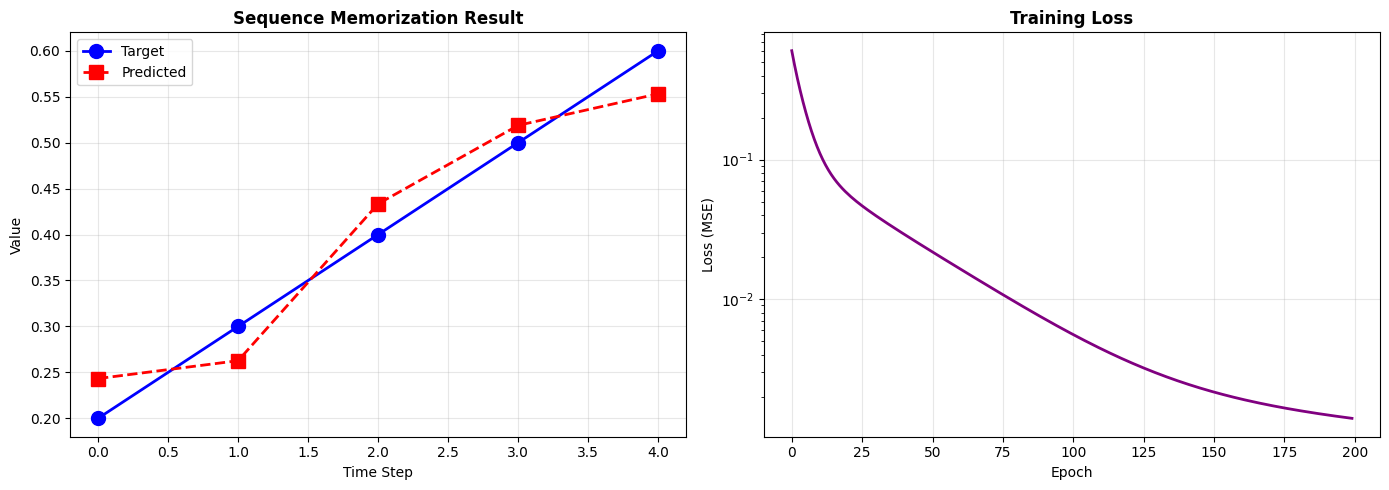

In [46]:
# Visualize the learning process
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Predictions
axes[0].plot(simple_target.squeeze().numpy(), 'bo-', linewidth=2, markersize=10, label='Target')
axes[0].plot(prediction[0, :, 0].detach().numpy(), 'rs--', linewidth=2, markersize=10, label='Predicted')
axes[0].set_title('Sequence Memorization Result', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Time Step')
axes[0].set_ylabel('Value')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Loss curve
axes[1].plot(rnn_simple.loss_history, 'purple', linewidth=2)
axes[1].set_title('Training Loss', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss (MSE)')
axes[1].grid(True, alpha=0.3)
axes[1].set_yscale('log')

plt.tight_layout()
plt.show()

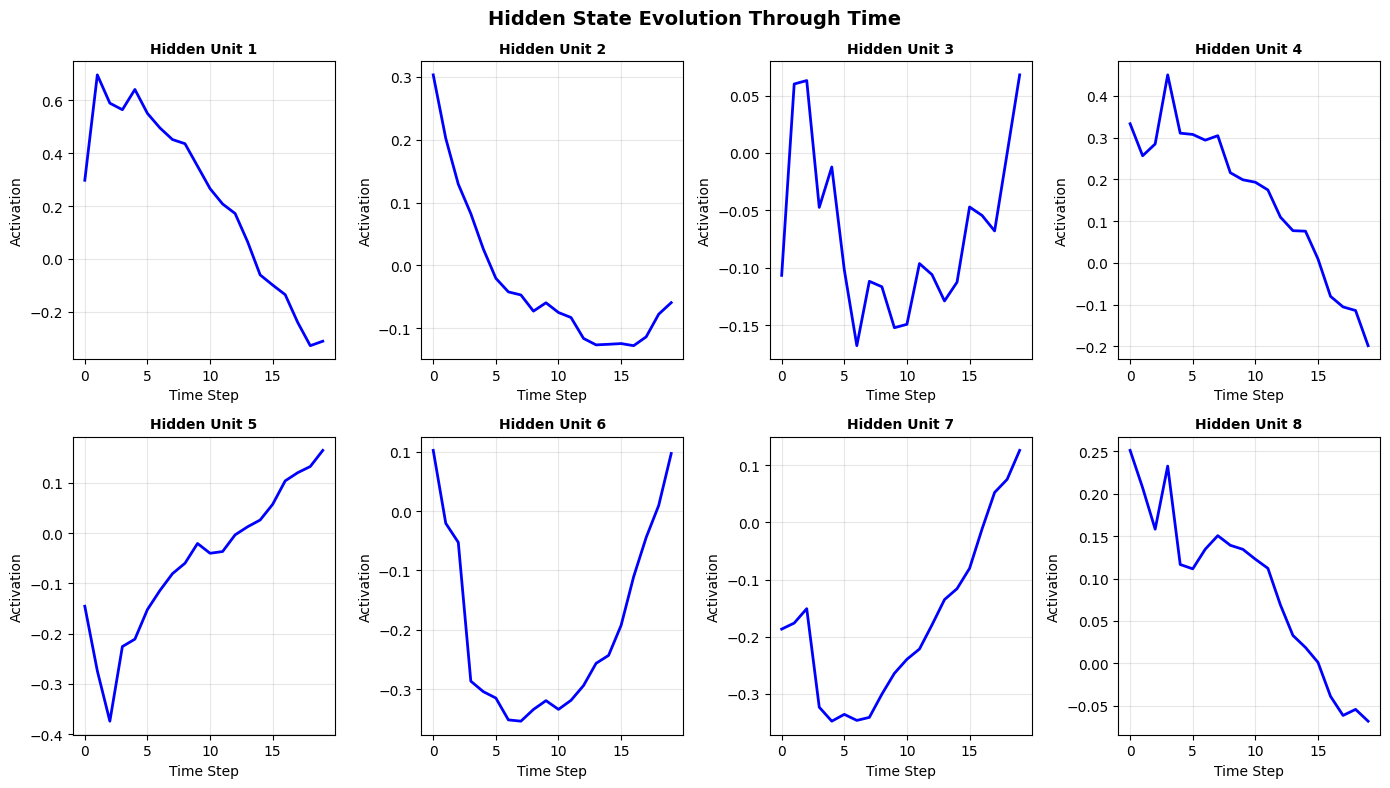

Each plot shows how one hidden unit's activation changes over time.
These hidden units capture temporal patterns in the input sequence.


In [47]:
# Track hidden states through sequence
test_input = X_sine[10:11]  # Single sine wave sequence
outputs, hidden_states, _ = rnn_sine.forward(test_input, return_hidden=True)

# Convert to numpy for plotting
hidden_array = torch.stack(hidden_states[1:], dim=0).squeeze().detach().numpy()  # (seq_len, hidden_size)

# Plot first 8 hidden units
plt.figure(figsize=(14, 8))

for i in range(min(8, rnn_sine.hidden_size)):
    plt.subplot(2, 4, i+1)
    plt.plot(hidden_array[:, i], 'b-', linewidth=2)
    plt.title(f'Hidden Unit {i+1}', fontsize=10, fontweight='bold')
    plt.xlabel('Time Step')
    plt.ylabel('Activation')
    plt.grid(True, alpha=0.3)

plt.suptitle('Hidden State Evolution Through Time', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("Each plot shows how one hidden unit's activation changes over time.")
print("These hidden units capture temporal patterns in the input sequence.")

In [48]:
print("=" * 70)
print("MANUAL FORWARD PASS CALCULATION")
print("=" * 70)

# Create tiny RNN for demonstration
tiny_rnn = RecurrentNeuralNetwork(input_size=1, hidden_size=2, output_size=1, learning_rate=0.1)

# Set simple weights
tiny_rnn.W_xh = torch.tensor([[0.5, 0.3]])
tiny_rnn.W_hh = torch.tensor([[0.2, 0.1], [0.3, 0.4]])
tiny_rnn.W_hy = torch.tensor([[0.6], [0.4]])
tiny_rnn.b_h = torch.tensor([0.1, 0.2])
tiny_rnn.b_y = torch.tensor([0.1])

print("\nNetwork: 1 input -> 2 hidden -> 1 output")
print(f"\nW_xh (input->hidden):\n{tiny_rnn.W_xh}")
print(f"\nW_hh (hidden->hidden):\n{tiny_rnn.W_hh}")
print(f"\nW_hy (hidden->output):\n{tiny_rnn.W_hy}")
print(f"\nb_h: {tiny_rnn.b_h}")
print(f"b_y: {tiny_rnn.b_y}")

# Input sequence (batch_size=1, seq_length=3, input_size=1)
input_seq = torch.tensor([[[0.5], [0.8], [0.3]]])
print(f"\nInput sequence: {input_seq[0, :, 0].tolist()}")

print("\n" + "=" * 70)
print("STEP-BY-STEP FORWARD PASS")
print("=" * 70)

# Manual computation
h = torch.zeros(2)
print(f"\nInitial h_0: {h.tolist()}")

for t in range(3):
    x_t = input_seq[0, t, :]
    print(f"\n{'='*70}")
    print(f"Time step t={t}")
    print(f"{'='*70}")
    print(f"Input x_{t}: {x_t.item():.4f}")
    
    # Compute hidden state
    z_h = x_t @ tiny_rnn.W_xh + h @ tiny_rnn.W_hh + tiny_rnn.b_h
    print(f"\nz_h = x @ W_xh + h @ W_hh + b_h")
    print(f"z_h = {z_h.tolist()}")
    
    h = torch.tanh(z_h)
    print(f"h_{t+1} = tanh(z_h) = {h.tolist()}")
    
    # Compute output
    y = h @ tiny_rnn.W_hy + tiny_rnn.b_y
    print(f"\ny_{t} = h @ W_hy + b_y")
    print(f"y_{t} = {y.item():.4f}")

# Verify with forward method
print(f"\n{'='*70}")
print("VERIFICATION")
print(f"{'='*70}")
output_verify = tiny_rnn.predict(input_seq)
print(f"Output (using forward method): {output_verify[0, :, 0].tolist()}")

MANUAL FORWARD PASS CALCULATION

Network: 1 input -> 2 hidden -> 1 output

W_xh (input->hidden):
tensor([[0.5000, 0.3000]])

W_hh (hidden->hidden):
tensor([[0.2000, 0.1000],
        [0.3000, 0.4000]])

W_hy (hidden->output):
tensor([[0.6000],
        [0.4000]])

b_h: tensor([0.1000, 0.2000])
b_y: tensor([0.1000])

Input sequence: [0.5, 0.800000011920929, 0.30000001192092896]

STEP-BY-STEP FORWARD PASS

Initial h_0: [0.0, 0.0]

Time step t=0
Input x_0: 0.5000

z_h = x @ W_xh + h @ W_hh + b_h
z_h = [0.3499999940395355, 0.3500000238418579]
h_1 = tanh(z_h) = [0.33637553453445435, 0.33637556433677673]

y_0 = h @ W_hy + b_y
y_0 = 0.4364

Time step t=1
Input x_1: 0.8000

z_h = x @ W_xh + h @ W_hh + b_h
z_h = [0.6681877970695496, 0.6081877946853638]
h_2 = tanh(z_h) = [0.5837865471839905, 0.5428501963615417]

y_1 = h @ W_hy + b_y
y_1 = 0.6674

Time step t=2
Input x_2: 0.3000

z_h = x @ W_xh + h @ W_hh + b_h
z_h = [0.5296123623847961, 0.5655187368392944]
h_3 = tanh(z_h) = [0.4850847125053406, 0.